In [2]:
%cd ~/code/entityrepresentations

/home/morand/code/entityrepresentations


## Imports

In [3]:
import torch, gc, sys, os, pathlib
import torch.nn as nn
import torch
import numpy as np
from jaxtyping import Float
from torch.utils.data import DataLoader
from datasets import load_dataset
import transformer_lens as tl 
from transformer_lens import HookedTransformer
from importlib import reload
from tqdm import tqdm

#our own code
import utils

from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2
        
IN_GITHUB = os.getenv("GITHUB_ACTIONS") == "true"
# from IPython.display import display
# import ipywidgets as widgets
# # reload(IPython.display)
# reload(widgets)
reload(utils)
from LabelExtractor import eval_model, compute_metrics, infer_entities
from processResults import *
reload(sys.modules['LabelExtractor'])

<module 'LabelExtractor' from '/home/morand/code/entityrepresentations/LabelExtractor.py'>

## Model Loading

In [10]:
# del model
gc.collect()
torch.cuda.empty_cache()

In [4]:
# Load a model (eg GPT-2 Small)
model_name = "bloom-3b" #crashed
model_name = "meta-llama/Meta-Llama-3-8B" # ?
model_name = "gpt2-small" # 117M ok
model_name = "gpt2-xl" # 1.5B ok
model_name = "gpt2-large" # 774M ok
model_name = "mistralai/Mistral-7B-v0.1" # ok JZ a100 8cpus | 
model_name = "gpt2-medium" # 302M ok
model_name = "phi-3" # 3,6B -> OK ?
model_name = "pythia-410m"# ok !
model_name = "pythia-1.4b"# ok ! (6Gb)
model_name = "pythia-2.8b"#ok !
model_name = "EleutherAI/pythia-6.9b"#? CRASHED
model_name = "phi-1_5"  # 1.5B ok
model_name = "phi-2" # 2,5B ok

#check if model variable exists
if not 'model' in locals():
    model = HookedTransformer.from_pretrained(
                                    model_name, 
                                    trust_remote_code = True, 
                                    # low_cpu_mem_usage = True, 
                                    device_map='auto',
                                    move_to_device=False,
                                    fold_ln=False,
                                    fold_value_biases=False,
                                    center_writing_weights=False,
                                    center_unembed=False,
                                    )
    print(model)
    model.eval()

model = model.cuda()
    # dim = model.QK.shape[-1]

/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loaded pretrained model phi-2 into HookedTransformer
HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-31): 32 x TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out

In [6]:
# print hooks
test_prompt = "The quick brown fox jumped over the lazy dog"
print("Num tokens:", len(model.to_tokens(test_prompt)[0]))
def print_name_shape_hook_function(activation, hook):
    print(hook.name, activation.shape)
not_in_late_block_filter = lambda name: name.startswith("blocks.0.") or not name.startswith("blocks")

model.run_with_hooks(
    test_prompt,
    return_type=None,
    fwd_hooks=[(not_in_late_block_filter, print_name_shape_hook_function)],
)

Num tokens: 10
hook_embed torch.Size([1, 10, 2560])
blocks.0.hook_resid_pre torch.Size([1, 10, 2560])
blocks.0.ln1.hook_scale torch.Size([1, 10, 1])
blocks.0.ln1.hook_normalized torch.Size([1, 10, 2560])
blocks.0.ln1.hook_scale torch.Size([1, 10, 1])
blocks.0.ln1.hook_normalized torch.Size([1, 10, 2560])
blocks.0.ln1.hook_scale torch.Size([1, 10, 1])
blocks.0.ln1.hook_normalized torch.Size([1, 10, 2560])
blocks.0.attn.hook_q torch.Size([1, 10, 32, 80])
blocks.0.attn.hook_k torch.Size([1, 10, 32, 80])
blocks.0.attn.hook_v torch.Size([1, 10, 32, 80])
blocks.0.attn.hook_rot_q torch.Size([1, 10, 32, 80])
blocks.0.attn.hook_rot_k torch.Size([1, 10, 32, 80])
blocks.0.attn.hook_attn_scores torch.Size([1, 32, 10, 10])
blocks.0.attn.hook_pattern torch.Size([1, 32, 10, 10])
blocks.0.attn.hook_z torch.Size([1, 10, 32, 80])
blocks.0.hook_attn_out torch.Size([1, 10, 2560])
blocks.0.ln2.hook_scale torch.Size([1, 10, 1])
blocks.0.ln2.hook_normalized torch.Size([1, 10, 2560])
blocks.0.mlp.hook_pre tor

In [7]:
#test if we get the right hook name
replace_hook_name = tl.utils.get_act_name('embed')
print(replace_hook_name)

hook_embed


## Atomic Tests

In [41]:
prompt, tok = "When Bob and France went to the store, Bob asked"            , 3
prompt, tok = "When Mary and Bob went to the store, Bob asked"              , 3
prompt, tok = "the French Iron King, aka '"                                 , 4
prompt, tok = "Alan Bean was an ", 2
prompt, tok = "Barack Obama was an ", 3
prompt, tok = "the molecule HU765DGB introduced herself: 'hi, my name is"   , 7
prompt, tok = "The Empire State Building is a great monument"               , 4

prompt, tok = "Alan Bean was an American astronaut, born on March 15, 1932 in Wheeler, Texas. He received a Bachelor of Science degree at the University of \
Texas at Austin in 1955 and was chosen by NASA in 1963. Alan Bean was a"   , 44
prompt, tok = "Man of steel, commonly known as"                             , 3
prompt, tok = "The Eiffel Tower is also known as the 'metal lady' in France."                                           , 5

### Test Generation

In [22]:
res = model.generate(prompt, max_new_tokens=20, temperature=0, return_type="str")
print(res)
# model.to_str_tokens(res)


  0%|          | 0/20 [00:00<?, ?it/s]

Man of steel, commonly known as Superman, is a fictional superhero created by Jerry Siegel and Joe Shuster. He


### Extract representation at given layer

In [ ]:
toks = model.to_str_tokens(prompt)
for i,t  in enumerate(toks): print(i, "\t", t, "  <--" if i==tok else "")

repr = utils.get_representation(model,
                                layer=9,
                                tokens=model.to_tokens(prompt),
                                token_inds=[tok],
                                verbose=True)

0 	 <|endoftext|> 
1 	 Alan 
2 	  Bean 
3 	  was 
4 	  an 
5 	  American 
6 	  astronaut 
7 	 , 
8 	  born 
9 	  on 
10 	  March 
11 	  15 
12 	 , 
13 	  1932 
14 	  in 
15 	  Wheeler 
16 	 , 
17 	  Texas 
18 	 . 
19 	  He 
20 	  received 
21 	  a 
22 	  Bachelor 
23 	  of 
24 	  Science 
25 	  degree 
26 	  at 
27 	  the 
28 	  University 
29 	  of 
30 	  Texas 
31 	  at 
32 	  Austin 
33 	  in 
34 	  1955 
35 	  and 
36 	  was 
37 	  chosen 
38 	  by 
39 	  NASA 
40 	  in 
41 	  1963 
42 	 . 
43 	  Alan 
44 	  Bean   <--
45 	  was 
46 	  a 
extract representation of tokens [44] at hook blocks.9.hook_resid_post


### Regererate Label from rep
Here we can observe that the last subject's token contain enough information to identify the subject.

In [ ]:
utils.generate_from_repr(model, 
                         repr, 
                         retr_prompt="_ is commonly known as", 
                         do_sample=True,)

['<|endoftext|>_ is commonly known as the "Father of the American Space Program".\n']


# Datasets


## WebNLG

### Import

In [250]:


# Load WebNLG dataset
dataset = load_dataset("web_nlg", "release_v3.0_en", trust_remote_code=True)

#optionnal, filter categories from datset
cat = ['Food'] #Categories to ignore
cat = None
if cat :
    dataset["train"] = [item for item in dataset["train"] if item["category"] not in cat]
    dataset["test"] = [item for item in dataset["test"] if item["category"] not in cat]

# Create dataset instances
train_dataset = utils.WebNLGDataset(dataset['train'], max_ent_length=20)
test_dataset = utils.WebNLGDataset(dataset['test'])


In [268]:
print("train length:", len(train_dataset))
print("test length:", len(test_dataset))
print("ex sample:", train_dataset[np.random.randint(len(train_dataset))])


train length: 37644
test length: 13008
ex sample: {'entity': 'United States', 'text': 'The location of the 11th Mississippi Infantry Monument is Seminary Ridge, Adams County, Pennsylvania, United States. The monument was established in the year 2000 and falls under the category of Contributing property.', 'id': 34227}


### Explore Dataset

In [205]:
N_train = len(dataset["train"])
print("training dataset: ",N_train)
print("random sample: ")
item = dataset["train"][np.random.randint(N_train)]
# print(item["text"])
item

training dataset:  13211
random sample: 


{'category': 'CelestialBody',
 'size': 5,
 'eid': 'Id14',
 'original_triple_sets': {'otriple_set': [['(66063)_1998_RO1 | Planet/apoapsis | "2.5498957060815E8"^^<http://dbpedia.org/datatype/kilometre>',
    '(66063)_1998_RO1 | Planet/meanTemperature | "265.15"^^<http://dbpedia.org/datatype/kelvin>',
    '(66063)_1998_RO1 | orbitalPeriod | 3.11291e+07',
    '(66063)_1998_RO1 | periapsis | 4.14984e+10',
    '(66063)_1998_RO1 | epoch | "2013-11-04"^^xsd:date'],
   ['(66063)_1998_RO1 | Planet/meanTemperature | "265.0"^^<http://dbpedia.org/datatype/kelvin>',
    '(66063)_1998_RO1 | Planet/apoapsis | "2.5498957060815E8"^^<http://dbpedia.org/datatype/kilometre>',
    '(66063)_1998_RO1 | epoch | "November 4, 2013"',
    '(66063)_1998_RO1 | orbitalPeriod | 3.11291e+07',
    '(66063)_1998_RO1 | periapsis | 4.14984e+10'],
   ['(66063)_1998_RO1 | Planet/meanTemperature | "265.0"^^<http://dbpedia.org/datatype/kelvin>',
    '(66063)_1998_RO1 | Planet/apoapsis | "2.5498957060815E8"^^<http://dbpedia.or

### Augment Dataset with subject representations

In [79]:
layer = 15 #layer where to extract representations
b_size = 50
print("Augmenting Train set with subject representations ... ")
train_dataset.augment_with_repr(model, layer, batch_size=b_size)
print("Augmenting Test set with subject representations ... ")
test_dataset.augment_with_repr(model, layer, batch_size=b_size)
print("Extraction of subjects representatons Done !\n")

Augmenting Train set with subject representations ... 


100%|█████████████████████████████████████████████████████████████████████████████| 753/753 [11:28<00:00,  1.09it/s]


Augmenting Test set with subject representations ... 


100%|█████████████████████████████████████████████████████████████████████████████| 261/261 [05:57<00:00,  1.37s/it]

Extraction of subjects representatons Done !



In [80]:
print(str(train_dataset[torch.randint(len(train_dataset),(1,))]).replace(", '", ",\n'"))

{'entity': 'Punjab, Pakistan',
'text': 'Allama Iqbal International Airport serves the city of Lahore and is located in Punjab Pakistan where the leader is Shehbaz Sharif.',
'id': 18887,
'representation': tensor([-0.4890, -0.4438,  0.2325,  ...,  0.1201,  0.2692, -0.3947])}


In [11]:
#ex sample from final dataset
test_dataset[67]["entity"]

'Alan Shepard'

### Inspect Dataset

In [12]:
import numpy as np
# get the first tokens of all entities
first_tokens = []
for i in range(len(train_dataset)):
    first_tokens.append(model.to_str_tokens(train_dataset[i]["entity"])[1])

# get counts of each token
unique, counts = np.unique(first_tokens, return_counts=True)

# sort by counts
sorted_tokens = sorted(zip(unique, counts), key=lambda x: x[1], reverse=True)
sorted_tokens[:30]


[('A', 2697),
 ('United', 2188),
 ('B', 1179),
 ('Al', 974),
 ('Ab', 644),
 ('S', 601),
 ('G', 519),
 ('New', 444),
 ('D', 429),
 ('English', 422),
 ('C', 387),
 ('F', 386),
 ('Washington', 379),
 ('M', 356),
 ('Alan', 354),
 ('J', 346),
 ('H', 337),
 ('Aaron', 334),
 ('K', 305),
 ('R', 299),
 ('P', 269),
 ('Ak', 259),
 ('Ar', 255),
 ('African', 242),
 ('N', 242),
 ('Ale', 241),
 ('L', 226),
 ('Ap', 224),
 ('V', 217),
 ('Ant', 214)]

## TACRED

### Loading

In [55]:
ds = load_dataset("AmirLayegh/tacred_text_label")
dataset_name = "TACRED"
i = np.random.randint(len(ds["train"]))
print("raw row example:", ds["train"][i])

train_dataset = utils.TacredDataset(ds["train"], max_ent_length=20,max_length=200)
test_dataset = utils.TacredDataset(ds["test"], max_ent_length=20,max_length=200)

#ex sample from final dataset
print("train length:", len(train_dataset))
print("test length:", len(test_dataset))
train_dataset[np.random.randint(len(train_dataset))]

raw row example: {'text': 'Survivors include five children , [object_start] Sharon Gude [object_end] of Rockville , Adrienne Gude of D.C. , [subject_start] Gilbert Gude Jr. [subject_end] and Gregory Gude , both of Bethesda , and Daniel Gude of Cabin John , Md. ; a brother , Rear Adm. William Callaghan of Rockville ; her stepmother , Sarah Callaghan of Chevy Chase ; and three grandchildren .  [subject_start] Gilbert Gude Jr. [subject_end] is American politician (1923-2007) and [object_start] Sharon Gude [subject_end] is American politician (1923-2007).', 'label': 'na'}
train length: 51506
test length: 11340


{'text': 'SAC Minister Tai Hsia-ling said the CAS might issue a ruling within three months of its decision to hear the appeal, which was filed on Dec. 8.',
 'entity': 'SAC',
 'id': 15506}

### Augmenting dataset with representations

In [11]:
i  =np.random.randint(len(train_dataset))
pr = train_dataset[i]["text"].replace("  ", " ")
print(pr)
model.to_str_tokens(pr)

Lehman -- that was before AIG, before the Big Three, before Madoff Securities.


['<|endoftext|>',
 'Le',
 'h',
 'man',
 ' --',
 ' that',
 ' was',
 ' before',
 ' A',
 'IG',
 ',',
 ' before',
 ' the',
 ' Big',
 ' Three',
 ',',
 ' before',
 ' Mad',
 'off',
 ' Securities',
 '.']

In [56]:
layer = 15 #layer where to extract representations
b_size = 100
# print("Augmenting Train set with subject representations ... ")
# train_dataset.augment_with_repr(model, layer, batch_size=b_size)
print("Augmenting Test set with subject representations ... ")
test_dataset.augment_with_repr(model, layer, batch_size=b_size)

Augmenting Test set with subject representations ... 


100%|█████████████████████████████████████████████████████████████████████████████| 114/114 [03:42<00:00,  1.95s/it]


### Check if Hf version has same data as official
we check in the [json sample](https://catalog.ldc.upenn.edu/desc/addenda/LDC2018T24.json) if we find the same sentences.

In [147]:
text = "Jeffrey White" # found 
text = "ranked 119"
text = "Douglas Flint" #found 
# search for the subject in the dataset
for split in ["train", "validation", "test"]:
    for i, item in enumerate(ds[split]):
        if item["text"].find(text) != -1:
            print(i, item)

580 {'text': "HSBC , [object_start] Europe [object_end] 's largest bank , on Friday said Stuart Gulliver , head of its investment arm , would replace Michael Geoghegan as chief executive and chose the bank 's finance director [subject_start] Douglas Flint [subject_end] to be its new chairman .  [subject_start] Douglas Flint [subject_end] is British businessman and [object_start] Europe [subject_end] is continent.", 'label': 'person countries of residence'}
638 {'text': 'Finance Director [subject_start] Douglas Flint [subject_end] was cautious about the outlook for U.S. consumer impairments , which he said hit around $ 3 billion in the third quarter , but said that there were recent positive trends in [object_start] U.S. [object_end] unemployment and house prices .  [subject_start] Douglas Flint [subject_end] is British businessman and [object_start] U.S. [subject_end] is country in North America.', 'label': 'person countries of residence'}
721 {'text': 'Finance Director [subject_start]

## SemEval
focused on semantic relation, without known entities

In [55]:
ds = load_dataset("SemEvalWorkshop/sem_eval_2010_task_8")
ds

DatasetDict({
    train: Dataset({
        features: ['sentence', 'relation'],
        num_rows: 8000
    })
    test: Dataset({
        features: ['sentence', 'relation'],
        num_rows: 2717
    })
})

In [86]:
i = np.random.randint(len(ds["train"]))
print(ds["train"][i])

{'sentence': 'The paired optic <e1>lobes</e1> of teleost <e2>fish</e2> are connected by two commissures.', 'relation': 2}


# Label Extraction task vector

## Train 

In [31]:
prepend_bos = True

dim = model.QK.shape[-1]
# create Task Vector
TaskVec = torch.normal(mean=0, std=1.0, size=(1,dim), requires_grad=True)

losses = []
accs = []
# TaskVec = torch.ones((1,d), requires_grad=True)

for param in model.parameters():
    param.requires_grad = False

Now we train our Taskvector in order to retreive the labels. 
We use the cross entropy loss, *i.e* : $$\ell(x,y)=L=\{l_1,\ldots,l_N\}^\top,\quad l_n=-w_{y_n}\log\frac{\exp(x_{n,y_n})}{\sum_{c=1}^C\exp(x_{n,c})}\cdot1$$
The TransformerLens implementation is [here](https://github.com/TransformerLensOrg/TransformerLens/blob/f4287b68d544b5fe1221739a4f3c2424eccf7d31/transformer_lens/utils.py#L115), **Warning**, it takes as input all the logits, and perform the shift **afterwards** !

In [36]:
#Training params
first_token_only = False
with_context = True
lr =2e-2
batch_size = 10
epochs = 10
log_per_epoch = 4

rep_idx = 1 if prepend_bos else 0 
taskVec_idx = rep_idx + 1
eos_tok = model.tokenizer.eos_token_id
eos_tok_str = model.tokenizer.eos_token

padding_tok = model.tokenizer.eos_token_id
replace_hook_name = tl.utils.get_act_name('embed') #pos_embed for gpt2 ... 

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
len_loader = len(train_dataloader)
n_log = len_loader // log_per_epoch
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
optim = torch.optim.Adam([TaskVec], lr=lr)
# optim = torch.optim.SGD([TaskVec], lr=lr)
# criterion = nn.CrossEntropyLoss()
gc.collect()
torch.cuda.empty_cache()
print(f"Starting training TaskVec for layer {layer} of {model_name}...")
for epoch in range(epochs):
    b_count = 0
    m_loss = 0
    for batch in tqdm(train_dataloader):
                
        b_count += 1
        entities = batch["entity"]
        texts = batch["text"]
        reps = batch["representation"].squeeze(1).cuda()
        b_size = reps.shape[0]
        b_taskVec = TaskVec.repeat(b_size,1).cuda()
        
        if first_token_only:
            entities = [toks[0] for toks in model.to_str_tokens(entities,prepend_bos=False)]
        else:    
            entities = [ent + eos_tok_str for ent in entities] # take whole label add eos token

        if with_context:
                    prompts = [txt + "_ >" for txt in texts]
                    context_toks = model.to_tokens(prompts, prepend_bos=prepend_bos, padding_side="left") 
                    entities_toks = model.to_tokens(entities, prepend_bos=False, padding_side="right")
                    inputs = torch.cat([context_toks, entities_toks], dim=1)
                    # print str of inputs 
                    # print(model.to_str_tokens(inputs[0]))
                    rep_idx = context_toks.shape[1] - 2
        else:
            rep_idx = 1 if prepend_bos else 0 
            prompts = ["_ > " + ent for ent in entities]
            inputs = model.to_tokens(prompts, prepend_bos=prepend_bos,)
        rep_idxs = torch.tensor(b_size * [rep_idx])
        taskVec_idxs = torch.tensor(b_size * [rep_idx + 1])            
        targets = inputs[:,rep_idx+1:] #don't take the '<eos>', <context>, '_' tokens into account

        logits = model.run_with_hooks(
                inputs,
                return_type = "logits",
                fwd_hooks=[
                    (replace_hook_name, utils.get_replace_with_rep_hook(reps, rep_idxs)), # replace '_' by the subject Representation
                    (replace_hook_name, utils.get_replace_with_rep_hook(b_taskVec, taskVec_idxs)) # replace 'called' by TaskVec Representation
                    ]
            ,)

        # LM Loss and optimization 
        loss = model.loss_fn(logits[:, rep_idx+1:,:], targets) # take only the loss on the entity tokens
        loss.backward()
        optim.step()
        optim.zero_grad()
        m_loss += loss.item()

        if b_count % n_log == 0:
            m_loss = m_loss / (len_loader // log_per_epoch)
            losses.append(m_loss)
            e = epoch + b_count/len_loader
            accs.append(eval_model(
                            model,
                            TaskVec,
                            test_loader=test_dataloader, 
                            first_token_only=first_token_only, 
                            with_context=with_context,
                            prepend_bos=prepend_bos))
            print(f"Epoch {e:.1f}, Batch {b_count}/{len_loader}, Loss: {m_loss:.3f}, Test Acc: {accs[-1]:.3f}")
            m_loss = 0

task = "LabelExtractor" if first_token_only else "FirstTokenExtractor"
fileName = f'{task}_{model_name}_l{layer}_e{len(losses)}.pth'


Starting training TaskVec for layer 15 of phi-1_5...


  0%|                                                                                      | 0/5151 [00:00<?, ?it/s]


['<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', 'She', ' stayed', ' at', ' her', ' home', ' in', ' Was', 'illa', ',', ' located', ' 40', ' miles', ' to', ' the', ' north', ',', ' but', ' was', ' expected', ' in', ' her', ' office', ' on', ' Friday', ',', ' spokesman', ' Bill', ' Mc', 'All', 'ister', ' said', '._', ' >', 'Bill', ' Mc', 'All', 'ister', '<|endoftext|>', '<|endoftext|>']


  0%|                                                                                      | 0/5151 [00:00<?, ?it/s]


['<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', 'ABC', ' leader', ' Tom', ' Th', 'ab', 'ane', ' accused', ' the', ' LCD', ' on', ' Wednesday', ' of', ' trying', ' to', ' stall', ' efforts', ' to', ' settle', ' the', ' dispute', ' in', ' the', ' courts', '._', ' >', 'ABC', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>']


...

['<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', 'In', ' his', ' speech', ',', ' R', 'aul', ' vowed', ' to', ' be', ' on', ' guard', ' against', ' U', '.', 'S', '.', ' ``', ' meddling', " ''", ' as', ' he', ' took', ' power', ' from', ' his', ' brother', ' Fidel', ' Castro', '._', ' >', 'U', '.', 'S', '.', '<|endoftext|>']


  0%|                                                                                      | 0/5151 [00:00<?, ?it/s]


['<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', 'His', ' wife', ',', ' who', ' accompanied', ' Y', 'oad', 'im', 'n', 'ad', 'ji', ' to', ' Paris', ',', ' will', ' repatri', 'ate', ' his', ' body', ' to', ' Chad', ',', ' the', ' ambassador', ' said', '._', ' >', 'Ch', 'ad', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>']


  0%|                                                                                      | 0/5151 [00:00<?, ?it/s]

['<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', 'Another', ' reason', ' behind', ' the', ' cut', ' is', ' the', ' f', 'irming', ' k', 'or', 'una', ' currency', ' which', ' is', ' now', ' two', ' percent', ' stronger', ' than', ' it', ' was', ' when', ' the', ' CN', 'B', ' last', ' discussed', ' monetary', ' policy', ' --', ' and', ' left', ' rates', ' on', ' hold', ' --', ' at', ' the', ' end', ' of', ' June', '._', ' >', 'C', 'NB', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>']


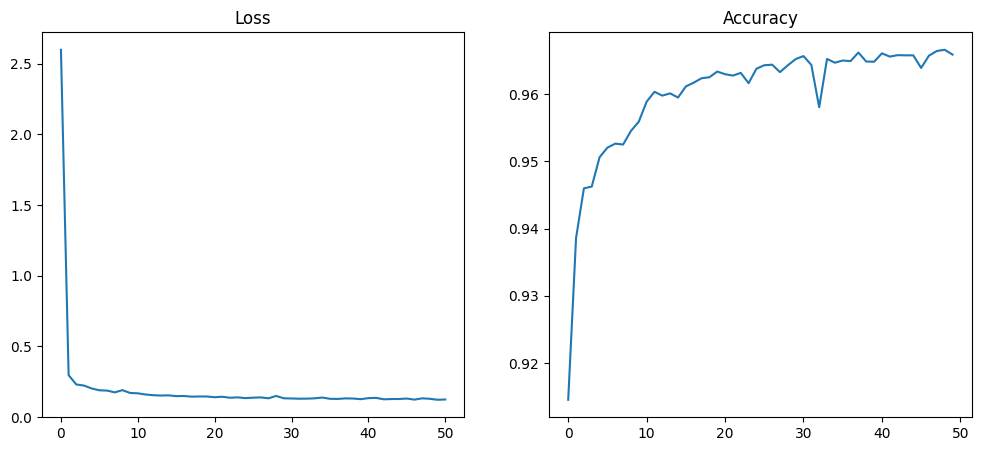

In [16]:
import matplotlib.pyplot as plt

# Create a figure and two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(losses)
ax2.plot(accs)
ax1.set_title("Loss")
ax2.set_title("Accuracy")
plt.show()

In [17]:
task = "LabelExtractor" if not first_token_only else "FirstTokenExtractor"
fileName = f'context{task}_{model_name}_l{layer}_e{len(losses)//log_per_epoch}.pth'

print("Saving TaskVec to ", fileName)
torch.save(TaskVec, fileName)

Saving TaskVec to  contextLabelExtractor_gpt2-medium_l15_e12.pth


## Testing the model

In [7]:
fileName = "./checkpoints/TaskVec_gpt2-small_l8_e50.pth"
fileName = "./LabelExtractor_gpt2-medium_l12_e9.pth"
fileName = "./checkpoints/TaskVec_mistral-7B_l17_e20.pth"
fileName = "./checkpoints/LabelExtractor_phi-2_l15_e20.pth"
fileName = "./checkpoints/contextLabelExtractor_phi-2_l15_e6.pth"
fileName = "./contextLabelExtractor_gpt2-medium_l15_e14.pth"

TaskVec = torch.load(fileName)
print("TaskVec loaded from ", fileName)

TaskVec loaded from  ./contextLabelExtractor_gpt2-medium_l15_e14.pth


In [8]:
test_dataloader = DataLoader(test_dataset, batch_size=20, shuffle=True)
eval_model(model, TaskVec, test_dataloader, prepend_bos=True, with_context=True)

0.9656465849338175

In [18]:
with_context = True
layer=15
data = test_dataset.data[:1000]
# test_dataset.data = data
# test_dataset.augment_with_repr(model, layer, batch_size=100)

for d in data:                  # drop inferered key in data
    d.pop("inferred", None)
acc = compute_metrics(model, TaskVec,
                       test_dataset,
                       with_context=with_context, 
                       max_tokens=20, b_size=20, prepend_bos=True)
print(f" Model {model_name}, layer {layer}:\n Evaluation metrics on test set:")
for k,v in acc.items():
    print(f"\t- {k}: {v:.3f}")
# print(f" Evaluation accuracy on train set: {acc:.3f}")

KeyError: 'inferred'

In [298]:
#print some fail examples
print("Original:".center(40) + " | " + "Inferred:".center(40)+ '\n'+"-"*84)
limit = 10
fails = set()
for item in data:
    if len(fails) >= limit: break
    item = data[np.random.randint(len(data))]
    if item['entity'] == item['inferred'] or item['inferred'] in fails: continue
    fails |= {item['inferred']}
    print(f"{item['entity'].center(40)} | {item['inferred'].center(40)}")

               Original:                 |                Inferred:                
------------------------------------------------------------------------------------
           Arlo Looking Cloud            |         Fritz Arlo Looking Cloud        
                  him                    |                   her                   
             Carol Daniels               |               Terry Jones               
             Eugenio Vagni               |              Andreas Notter             
               Ilan Ramon                |               Faris Jawad               
                 ALICO                   |       American International Group      
                Chen Tao                 |            Professor Chen Tao           
                  she                    |                   She                   
             The Federation              |                Federation               
                  She                    |                   she           

In [11]:
#print some with context
print("Original:".center(40) + " | " + "Inferred:".center(40)+ '\n'+"-"*84)
limit = 10
fails = set()
for item in data:
    if len(fails) >= limit: break
    item = data[np.random.randint(len(data))]
    if item['entity'] == item['inferred'] or item['inferred'] in fails: continue
    fails |= {item['inferred']}
    print(f"\n{item['entity'].center(40)} | {item['inferred'].center(40)}")
    print(f"context: {item['text']}")

               Original:                 |                Inferred:                
------------------------------------------------------------------------------------

                 Aquash                  |                  Kamook                 
context: But Kamook implicated Peltier all over again in the deaths of 2 FBI agents at a famous shootout on Pine Ridge a few months before Aquash turned up dead.

               right now                 |          the Corporate Library          
context: `` I 'm sure there are probably people working on that right now, '' said Paul Hodgson, senior research associate for the Corporate Library, a corporate governance research firm.

               Last month                |              the first year             
context: Last month, the American Association of University Women reported that in the first year after graduating, women working full-time make 20 percent less on average than their male classmates.

            accepting bri

In [15]:

dataset = test_dataset
ind = np.random.randint(len(dataset))
prompt = dataset[ind]["text"]
print(prompt)
print("target:", dataset[ind]["entity"])
# s = dataset[ind]["representation"].view(1,-1)

# s = repr
# gen = utils.generate_from_repr(model, s, TaskVec, retr_prompt="_ >", max_tokens=10, do_sample=True)
# print("generation:","".join(gen[3:-1]))

Director Ray Griggs, born in 1974, is the writer of the film Super Capers, starring Michael Rooker and Tom Sizemore.
target: Michael Rooker


In [43]:

def generate_from_repr( model, 
                        repr, 
                        taskVector = None, 
                        retr_prompt:str ="_ named",
                        max_tokens = 10,
                        do_sample = False,
                        prepend_bos=True,
                        ):
        """
        Args:
                repr: The representation vectors
                Model: the GPT model to use
                taskVector: the task vector to use. If None, will use default prompt
                max_tokens: num of tokens to generate
                do_sample: if True, sample from logits, else take argmax
                prepend_bos: if True, prepend '<BOS>' token to the input

        """
        inp_toks = model.to_tokens(retr_prompt, prepend_bos=prepend_bos)
        rep_idx = 1 if prepend_bos else 0
        replace_hook_name = tl.utils.get_act_name('embed')
        taskVec_idx = rep_idx + 1
        
        if taskVector is not None:
            taskVector = taskVector.view(1,-1)
            b_taskVec = taskVector.repeat(repr.shape[0],1).cuda()
        
        repr = repr.cuda()
        # print(b_taskVec.shape)
        # print(repr.shape)
        
        for i in range(max_tokens):
                # print(inputs, targets)
                if taskVector is not None:
                    logits = model.run_with_hooks(
                            inp_toks,
                            return_type = "logits",
                            fwd_hooks=[
                            (replace_hook_name, utils.get_replace_with_rep_hook(repr, torch.tensor([rep_idx]))), # replace '_' by the subject Representation
                            (replace_hook_name, utils.get_replace_with_rep_hook(b_taskVec, torch.tensor([taskVec_idx]))) # replace 'called' by TaskVec Representation
                            ])
                else:
                    logits = model.run_with_hooks(
                            inp_toks,
                            return_type = "logits",
                            fwd_hooks=[
                            (replace_hook_name, utils.get_replace_with_rep_hook(repr, torch.tensor([rep_idx]))), # replace '_' by the subject Representation
                            ])

                final_logits =  logits[0,-1,:] #extract logits for last token 

                if do_sample:
                        new_tok = tl.utils.sample_logits(
                        final_logits,
                        top_k=None,
                        top_p=None,
                        temperature=0,
                        freq_penalty=0,
                        tokens=inp_toks,
                        ).view(1,-1)
                else:       #greedy generation
                        new_tok = final_logits.argmax(-1).view(1,-1) 
                
                inp_toks = torch.hstack((inp_toks,new_tok))
                # stop if EOS token
                if new_tok == model.tokenizer.eos_token_id: break
        print(inp_toks)
        return model.tokenizer.decode(inp_toks.view(-1)[1:])

In [16]:
with_context = True
#funny widget to select a word 
# Split the text into words
prompt = train_dataset[np.random.randint(len(train_dataset))]["text"]
# prompt = " _ > Agnes Kant"
# prompt = "Alan Bean was an American astronaut, born on March 15, 1932 in Wheeler, Texas. He received a Bachelor of Science degree at the University of Texas at Austin in 1955 and was chosen by NASA in 1963. _ > Alan Bean"
words = model.to_str_tokens(prompt)

# Callback function to update selected word
def on_button_click(b):
    selected_word_label.value = f"Selected Word: {b.description}"
    layer = dropdown.value
    repr = utils.get_representation(model,
                                layer=layer,
                                tokens=model.to_tokens(prompt),
                                token_inds=torch.tensor([b.id]),
                                verbose=True)
    print(with_context)
    #change button color
    b.style.button_color = 'lightgreen'
    #change all others to default
    for button in buttons:
        if button.id != b.id:
            button.style.button_color = 'white'
    data = [{
        "id":0,
        "representation": repr,
        "text": prompt
        }]
    infer_entities(model, TaskVec, data, with_context=with_context)
    print("generation:", data[0]["inferred"])

# Buttons for each word
buttons = []
class clickableToken(widgets.Button):
    def __init__(self, id:int, description:str, **kwargs):
        super().__init__(description=description, **kwargs)
        self.description = description
        self.id = id
        self.on_click(on_button_click)

for ind, token in enumerate(words):
    buttons.append(
        clickableToken(
            id=ind, 
            description=token,
            layout=widgets.Layout(width='auto', margin='2px', padding='0 5px')
        ))
    

# Box widget with flexible wrapping
button_box = widgets.Box(
    children=buttons,
    layout=widgets.Layout(display='flex', flex_flow='row wrap', align_items='center')
)
# Dropdown widget for selecting an integer
dropdown = widgets.Dropdown(
    options=[(f"layer {i}", i) for i in range(len(model.blocks)-1, -1, -1)],
    description='Select a layer:',
    disabled=False,
)

def on_checkbox_change(change):
    global with_context
    with_context = change['new']

# Create the checkbox widget
with_context_checkbox = widgets.Checkbox(
    value=with_context,
    description='Generate with context',
    disabled=False
)
# Link the function to the checkbox change event
with_context_checkbox.observe(on_checkbox_change, names='value')

# Label to display the selected word
selected_word_label = widgets.Label()

# Create a title using HTML widget
title = widgets.HTML(value="<h3>Select a Token to generate from:</h3>")

# Display widgets
display(title)
display(button_box)
#display checkbox  and dropdown side by side
display(widgets.HBox([with_context_checkbox, dropdown]))
display(selected_word_label)

HTML(value='<h3>Select a Token to generate from:</h3>')

Box(children=(clickableToken(description='<|endoftext|>', layout=Layout(margin='2px', padding='0 5px', width='…

Label(value='')

extract representation of tokens tensor([32]) at hook blocks.15.hook_resid_post
True
generation: Retired 11
extract representation of tokens tensor([3]) at hook blocks.15.hook_resid_post
True
generation: Retired
extract representation of tokens tensor([3]) at hook blocks.15.hook_resid_post
False
generation: Albert Einstein
extract representation of tokens tensor([32]) at hook blocks.15.hook_resid_post
False
generation: References
extract representation of tokens tensor([37]) at hook blocks.15.hook_resid_post
False
generation: NASA


In [60]:
limit = 1000
layer = 17
test_dataset.data = test_dataset.data[:limit]
print("length:",len(test_dataset))
test_dataset.augment_with_repr(model, layer, batch_size=20)

length: 1000


100%|███████████████████████████████████████████████████████████████████████████████| 50/50 [00:53<00:00,  1.08s/it]


In [ ]:
## Check how does the model reads the TaskVec
utils.generate_from_repr(model, repr, TaskVec, retr_prompt="_ >", do_sample=True)

## Conclusion
The model is able to generate text from a representation of a subject.
It can do it for known entities, but likely not for representations of an unknown label (unknow name), even if there are clues that it knows where to look.
- adding the representation makes Phi1.5 model jump from 75 to 85% LM accuracy.
- But only 25% for the first token, whereas it can reach 32% if it is trained solely on predicting the first token 

`LabelExtrator_phi-1_5_l15_e30.pth` is a banger ! On train set..


# Convergence of representations
During Representation Construction
Here, we explore how the representation that we extract from the model is constructed by the Transformer.

### Compute cache

In [89]:
#get one example from the dataset
ind = np.random.randint(len(test_dataset))
# ind = 9296
print(f"sample {ind} from test dataset")
target = test_dataset[ind]["entity"]
prompt = test_dataset[ind]["text"] + ' ' + target
toks = model.to_str_tokens(prompt)

#tokenize the prompt
print( "prompt:", test_dataset[ind]["text"])
print( "|".join(toks))
print(f"{len(toks)} tokens, target:{target}")

layer = 17
hooks = [ # name, type, color
        ["normalized","ln1", "green"],
        ["attn_out","", "blue"],
        ["normalized","ln2", "lightgreen"],
        ["mlp_out","", "cyan"],
        ["resid_post","","red"]
        ]
# print hooks 
print("will use hooks:")          
for h,t,_ in hooks:
    hook = tl.utils.get_act_name(h, 0, t)
    print(hook)
similarities = torch.zeros(len(toks), len(hooks) * model.cfg.n_layers)
n = len(hooks)

#get whole hidden states
_ , cache = model.run_with_cache(prompt)
repr = cache[tl.utils.get_act_name("resid_post", layer, "")][:,-1,:] # 1 x n_tokens x dim
repr = repr.cuda().view(1,1,-1)

for l in range(model.cfg.n_layers):
    for i, (h,t,_) in enumerate(hooks):
        hook = tl.utils.get_act_name(h, l, t)
        reprs = cache[hook] # 1 x n_tokens x dim
        #compute similarities with the target representation
        sim = torch.cosine_similarity(reprs, repr, dim=-1)
        similarities[:,n*l+i] = sim.squeeze(0)

#add embeddings
hook = tl.utils.get_act_name("embed")
reprs = cache[hook] # 1 x n_tokens x dim
sim = torch.cosine_similarity(reprs, repr, dim=-1).cpu().detach().view(-1,1)
similarities = torch.hstack((sim, similarities )).cpu().detach().numpy()

del cache
gc.collect()
torch.cuda.empty_cache()

sample 8158 from test dataset
prompt: Wen 's wife Zhou Xiaoya and three senior Chongqing police officers - Huang Daiqiang, Zhao Liming and Chen Tao - will also receive their verdicts at the same court Wednesday afternoon.
<|endoftext|>|W|en| '|s| wife| Zhou| Xia|oya| and| three| senior| Chong|q|ing| police| officers| -| Huang| Dai|q|iang|,| Zhao| Lim|ing| and| Chen| Tao| -| will| also| receive| their| verdict|s| at| the| same| court| Wednesday| afternoon|.| Chen| Tao
45 tokens, target:Chen Tao
will use hooks:
blocks.0.ln1.hook_normalized
blocks.0.hook_attn_out
blocks.0.ln2.hook_normalized
blocks.0.hook_mlp_out
blocks.0.hook_resid_post


## Plotting Convergence to extracted representation

#### Plot Everything

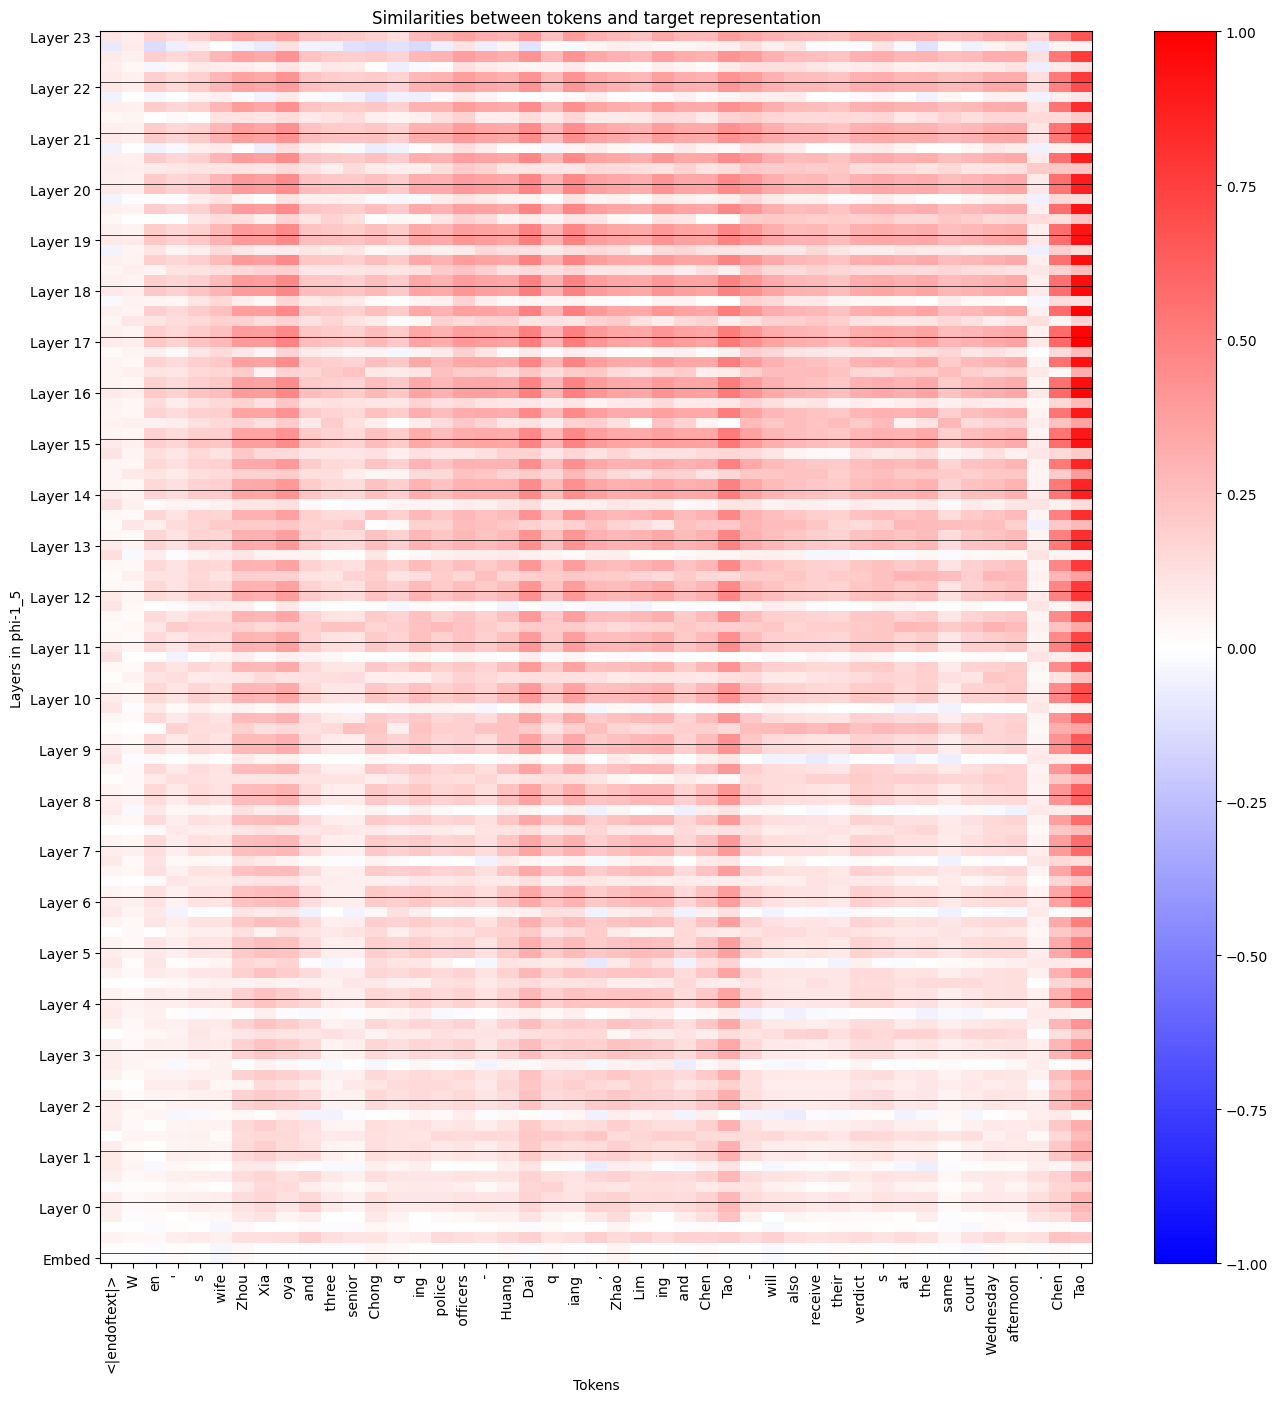

In [90]:
import matplotlib.pyplot as plt

#show image of similarities
plt.figure(figsize=(16,16))
plt.imshow(similarities.T, aspect='auto', cmap='bwr')
plt.colorbar()
#colorbar with scale from 0 to 1
#draw lines separating layers
for i in range(model.cfg.n_layers + 1):
    plt.axhline(y=n*i+.5, color='black', linewidth=0.5)
plt.clim(-1,1)
plt.title("Similarities between tokens and target representation")
plt.ylabel(f"Layers in {model_name}")
plt.gca().invert_yaxis() #invert y axis
plt.yticks(np.array(range(0,1 + n*model.cfg.n_layers,n)), ["Embed"] + [f"Layer {i}" for i in range(model.cfg.n_layers)])
plt.xlabel("Tokens")
plt.xticks(range(len(toks)), toks, rotation=90)
plt.show()

#### Plot output of all layers

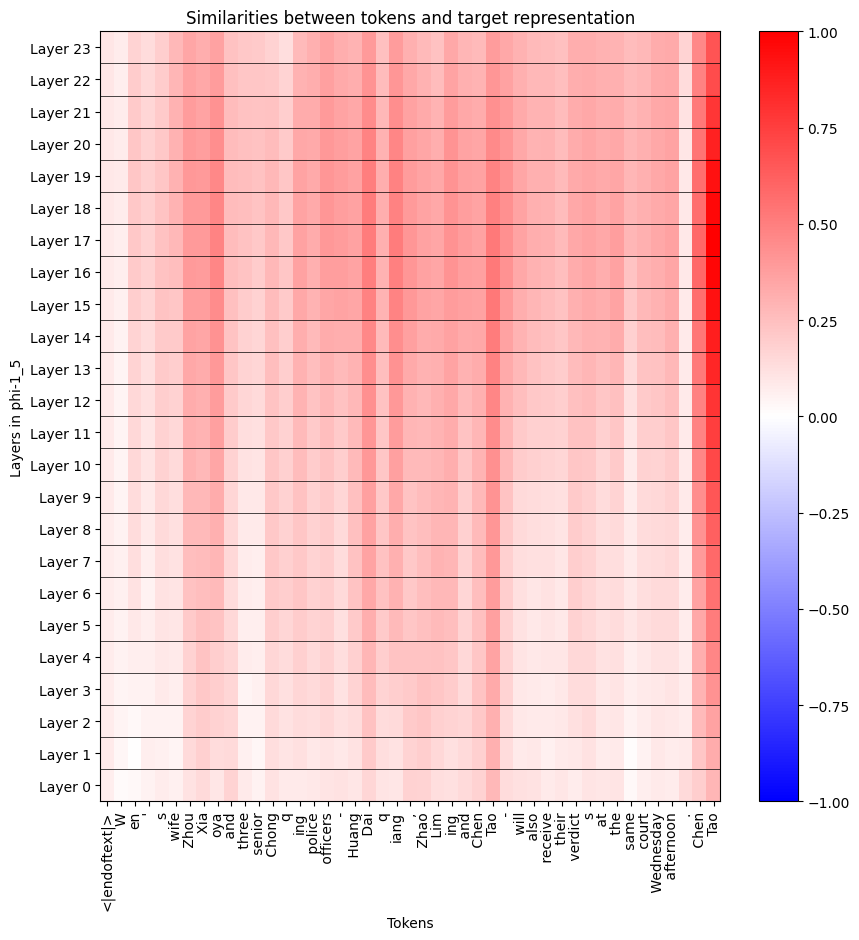

In [91]:
outputs_only = np.zeros((len(toks), model.cfg.n_layers))
for i in range(model.cfg.n_layers):
    outputs_only[:,i] = similarities[:,n*(i+1)] # 1 + n*(i+1) - 1
#show image of similarities
plt.figure(figsize=(10,10))
plt.imshow(outputs_only.T, aspect='auto', cmap='bwr')
plt.colorbar()
#colorbar with scale from 0 to 1
#draw lines separating layers
for i in range(model.cfg.n_layers):
    plt.axhline(y=i+.5, color='black', linewidth=0.5)
plt.clim(-1,1)
plt.title("Similarities between tokens and target representation")
plt.ylabel(f"Layers in {model_name}")
plt.gca().invert_yaxis() #invert y axis
plt.yticks(np.array(range(0,model.cfg.n_layers)), [f"Layer {i}" for i in range(model.cfg.n_layers)])
plt.xlabel("Tokens")
plt.xticks(range(len(toks)), toks, rotation=90)
plt.show()

#### Plot for Last token

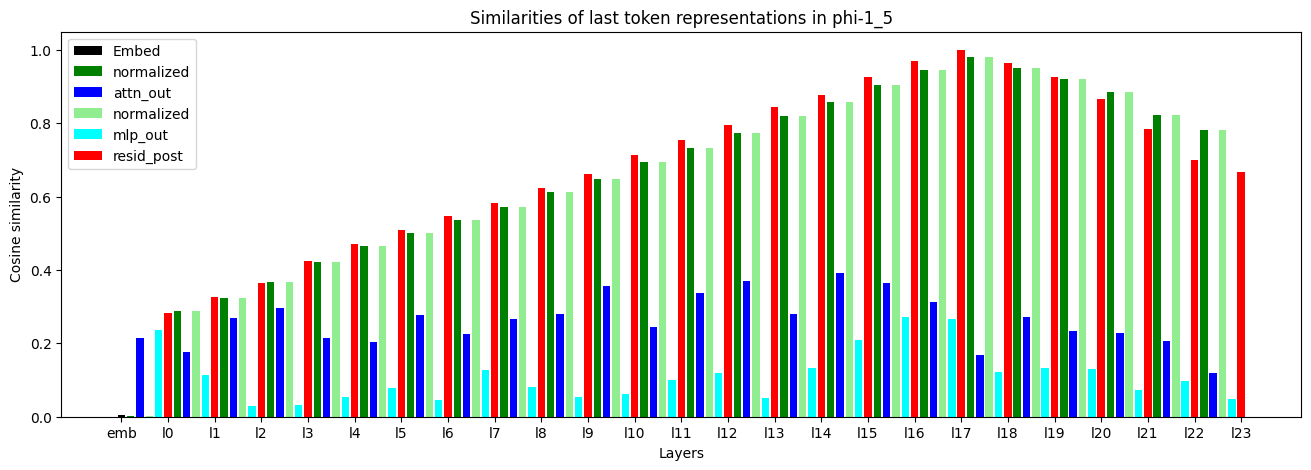

In [92]:
#plot the last token similarities
plt.figure(figsize=(16,5))
#color all multiples of n in red 
colors = ["black"] + [c for _,_,c in hooks]*(model.cfg.n_layers)
labels = ["Embed"] + [h for h,_,_ in hooks] + ['_' + h for h,_,_ in hooks]*(model.cfg.n_layers - 1)

plt.bar(range(similarities.shape[1]),similarities[-1,:], label=labels, color=colors)

plt.title(f"Similarities of last token representations in {model_name}")
plt.ylabel("Cosine similarity")
plt.xlabel("Layers")
plt.xticks(range(0, n*model.cfg.n_layers + 1, n), ["emb"] + [f"l{i}" for i in range(model.cfg.n_layers)])
plt.legend()
plt.show()

#### Plot for given Layer

/tmp/ipykernel_2757091/55035363.py:11: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



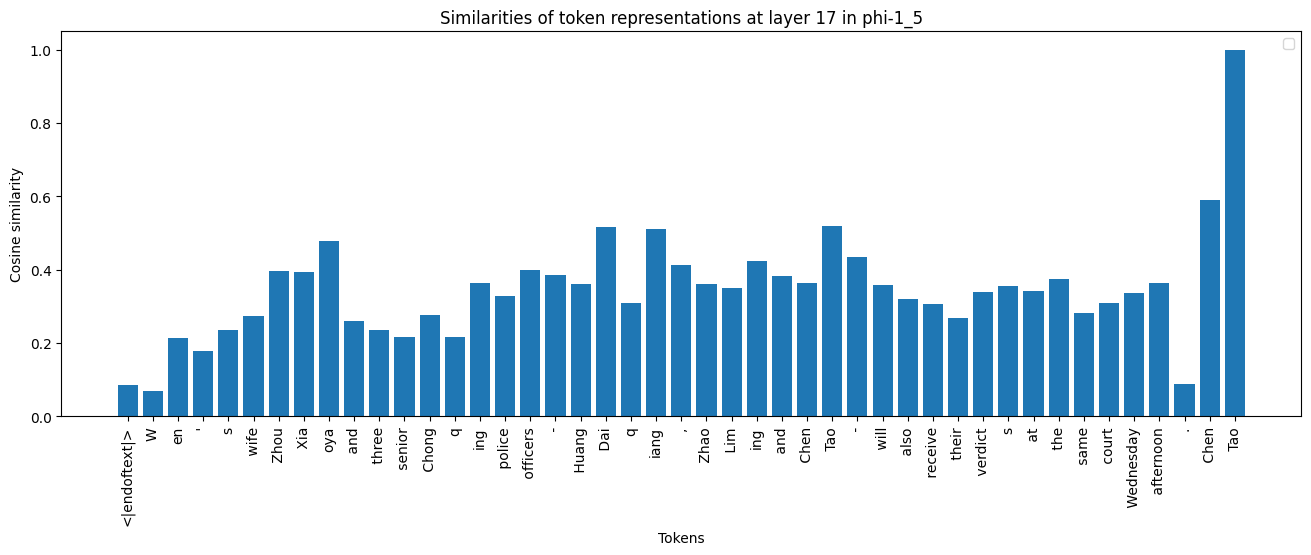

In [93]:
#plot the last token similarities
plt.figure(figsize=(16,5))

outputs = [similarities[i,n*(layer+1)] for i in range(len(toks))]
plt.bar(range(len(outputs)), outputs)

plt.title(f"Similarities of token representations at layer {layer} in {model_name}")
plt.ylabel("Cosine similarity")
plt.xlabel("Tokens")
plt.xticks(range(len(toks)), toks, rotation=90)
plt.legend()
plt.show()

# Attention Dissection

In [6]:
import circuitsvis as cv
import plotly.io as pio
# Plotly needs a different renderer for VSCode/Notebooks vs Colab argh
pio.renderers.default = "notebook_connected"
print(f"Using renderer: {pio.renderers.default}")
# Testing that the library works
cv.examples.hello("Victor")


Using renderer: notebook_connected


In [46]:
#get one example from the dataset
ind = np.random.randint(len(test_dataset))
# ind = 9296
print(f"sample {ind} from test dataset")
target = test_dataset[ind]["entity"]
context = test_dataset[ind]["text"]
prompt = context + ' ' + target # prompt used to build the representations
str_tokens = model.to_str_tokens(prompt)

#get whole cache for given prompt as it is done in 'augment_with_repr'
_ , cache = model.run_with_cache(prompt)

#display the prompt
html = cv.tokens.colored_tokens(str_tokens,[])
html.cdn_src = html.cdn_src.replace("margin: 15px", "margin: 50px")
html
#add padding at the end of html

sample 8331 from test dataset


## Attention while constructing the representation
Here, we just explore the use of `cv.attention.attention_patterns` function from `circuitsvis` that allows us to inspect the attention scores for each head of our model when run on the prompt that was used to retreive the representations

In [8]:
layer = 10
print(type(cache))
attention_pattern = cache["pattern", layer, "attn"].squeeze(0)
print("pattern shape:", attention_pattern.shape)
print(f"Layer {layer} Head Attention Patterns:")
cv.attention.attention_patterns(tokens=str_tokens, attention=attention_pattern)

<class 'transformer_lens.ActivationCache.ActivationCache'>
pattern shape: torch.Size([32, 27, 27])
Layer 10 Head Attention Patterns:


## Attention while generating labels
Now, we explore what is happening on the attention side when we perform the label generation. 

### Retrieve corresponding Trained TaskVector

In [9]:
layer = 8
with_context = True
# load results
xp_path = pathlib.Path.home() / "experiments_JeanZay"
#get all experiments directories
xp_paths= os.listdir(xp_path / "jobs")
jobs_path = xp_path / "jobs" / xp_paths[0]
#get jobs
print("loading all results from ", jobs_path)
results = loadResults(jobs_path)
# Get TaskVec from the model
fileName = get_taskVec(results, model_name, layer=layer, dataset_name=dataset_name, with_context = with_context)
TaskVec = torch.load(fileName)
print("TaskVec loaded from ", fileName)

loading all results from  /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor


100%|█████████████████████████████████████████████████████████████████████████████| 550/550 [00:24<00:00, 22.19it/s]


found 1 results for layer 8 of phi-2 with context on TACRED
found ['TaskVec_phi-2_l8_e20.pth'] 
TaskVec loaded from  /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/1d00fd765088c11703fbc0e36331dbd9cb4adf8f2617786b9c747ad6097f819a/TaskVec_phi-2_l8_e20.pth


### Generate with TaskVec

In [73]:
#get all representations at given layer from cache
repr = cache[tl.utils.get_act_name("resid_post", layer, "")][0,-1,:] # n_tokens x dim
repr = repr.detach().cuda()
data = [{"id": 0, "text": context, "representation": repr, }]
infer_entities2(model, TaskVec, data, with_context=with_context,
                return_attn_pattern=True,
                )
print("inferred '",data[0]["inferred"],"' from representation extracted at layer", layer, "of model", model_name) 

#get the attention pattern for the inferred entity at the given layer
pattern = data[0]["attn_pattern"][18]
str_tokens = model.to_str_tokens(context + ' _ > ' + data[0]["inferred"])
print(f"Layer {layer} Head Attention Patterns:")
cv.attention.attention_patterns(tokens=str_tokens, attention=pattern)

100%|█████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.75it/s]

inferred ' AAUW ' from representation extracted at layer 15 of model phi-2
Layer 15 Head Attention Patterns:


In [ ]:
replace_hook_name = tl.utils.get_act_name('embed')
hook_pattern = tl.utils.get_act_name("pattern", layer, "attn")

print(hook_pattern)
attention_pattern = torch.zeros((model.cfg.n_heads, len(str_tokens), len(str_tokens)), device=model.cfg.device)
print(attention_pattern.shape)
#def ineer function to get the attention pattern
def get_attn(
    pattern: Float[torch.Tensor, "batch head_index dest_pos source_pos"],
    hook,
    ):
    #get the attention pattern from hook name : hacky
    l = hook.name.split(".")[1]
    print(pattern.shape)
    attention_pattern[:,l,:,:] = pattern.cpu().detach()

model.run_with_hooks(
    prompt,
    return_type=None,
    fwd_hooks=[ (hook_pattern, get_attn),
                (replace_hook_name, utils.get_replace_with_rep_hook(reps, rep_idxs)), # replace '_' by the subject Representation
                (replace_hook_name, utils.get_replace_with_rep_hook(b_taskVec, taskVec_idxs)) # replace 'called' by TaskVec Representation
                ],
    )

In [67]:
#delete 'inferred' key from data
data = test_dataset[:100]
for d in data: d.pop("inferred", None)

In [68]:
infer_entities(model, TaskVec, data, with_context=True, b_size=5)

In [69]:
infer_entities2(model, TaskVec, data, with_context=True, return_attn_pattern=False, b_size=5)

100%|███████████████████████████████████████████████████████████████████████████████| 20/20 [00:10<00:00,  1.99it/s]


In [ ]:
infer_entities2(model, TaskVec, test_dataset, with_context=True, return_attn_pattern=False, b_size=5)

100%|███████████████████████████████████████████████████████████████████████████| 2268/2268 [21:13<00:00,  1.78it/s]


In [62]:
compute_metrics(model, TaskVec, test_dataset, with_context=True, max_tokens=20, b_size=20, 
                force_recompute=False)

100%|█████████████████████████████████████████████████████████████████████| 11340/11340 [00:00<00:00, 490202.90it/s]


{'Partial Match': 0.9805996472663139,
 'Exact Match': 0.9587301587301588,
 'Chr-F': 97.73625972706623,
 'Version': 1.2}

# Misc
## Correlation between reconstructions and representations counts in the Pile

In [ ]:
res = []
counts = {}

In [ ]:
import requests, time

payload = {
    'corpus': 'v4_piletrain_llama',
    'query_type': 'count',
    'query': 'University of Washington',
}

for item in tqdm(test_dataset):
    entity = item["entity"]
    if entity not in counts:
        payload['query'] = entity
        result = requests.post('https://api.infini-gram.io/', json=payload).json()
        time.sleep(0.001)
        counts[entity] = result['count']

print(counts)



100%|█████████████████████████████████████████████████████████████████████████| 13015/13015 [02:29<00:00, 86.89it/s]

{'Brazil': 4863867, "''Alvinegro": 0, 'Agremiação Sportiva Arapiraquense': 52, 'Arapiraca': 536, 'Campeonato Brasileiro Série C': 1462, 'Nie Haisheng': 289, 'Fighter pilot': 743, 'Fawkham': 311, 'MotorSport Vision': 323, 'FC Spartak Moscow': 2063, 'Aleksandr Prudnikov': 14, 'Otkrytiye Arena': 73, 'City Manager': 71202, 'Council-manager government': 56, 'City': 24023624, 'Ciudad Ayala': 78, '1969: The Velvet Underground Live': 92, 'Bootleg Series Volume 1: The Quine Tapes': 45, 'Squeeze': 103003, 'Governator': 3395, 'Mexico': 6275874, 'Pacific Daylight Time': 2949, 'Olga Bondareva': 17, 'Saint Petersburg': 116778, 'Piotr Hallmann': 190, 'Darlington': 121147, 'Contributing property': 69, 'Franklin County, Pennsylvania': 2340, 'Adams County, Pennsylvania': 2385, 'Gettysburg, Pennsylvania': 5921, 'Cumberland County, Pennsylvania': 2095, '11th Mississippi Infantry Monument': 122, 'Israel': 10001449, 'Modern Hebrew': 4658, 'Alcobendas': 2940, 'ENAIRE': 170, 'Adolfo Suárez Madrid–Barajas Airp

In [ ]:
print(len(counts))
#save counts
import json
with open('test_entities_counts.json', 'w') as f:
    json.dump(counts, f)

566
